In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torch.utils.data as data
from torch.utils.data import Subset
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm
import math
from models.unet import UNet
from utils import check_posterior_logic, verify_training_inputs, check_noise_correlation, visualise_loader, make_beta_schedule, periodic_sample_grids, ancestral_sample, plot_ancestral_samples, plot_sampling_norms
from diffusion.diffusion import DiffusionProcess

In [29]:
EPOCHS = 50
L = 1000
BATCH = 128

device = "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"
print(f"Device: {device}")

Device: cuda


In [30]:
# Loading MNIST dataset
# Convert to tensor and normalize between -1 and 1
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
train_loader = data.DataLoader(train_dataset, batch_size=BATCH, shuffle=True, num_workers=4)

test_dataset = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)
test_loader = data.DataLoader(test_dataset, batch_size=BATCH, shuffle=False, num_workers=4)
    

# Schedule Ablation

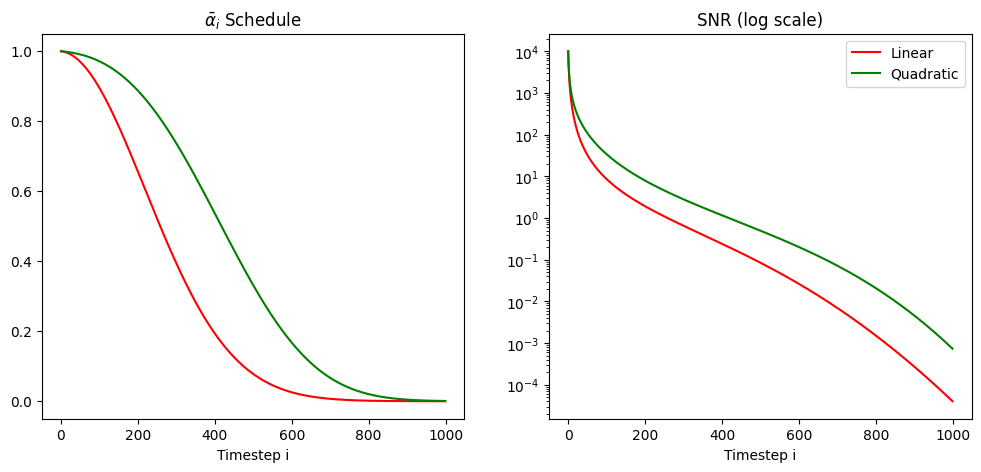

In [31]:
lin_diff = DiffusionProcess(L=1000, device=device)
lin_alphas_bar = lin_diff.alphas_cumprod.to("cpu").numpy()
lin_snr = lin_alphas_bar / (1 - lin_alphas_bar)

quad_diff = DiffusionProcess(L=1000, device=device, beta_schedule_type="quadratic")
quad_alphas_bar = quad_diff.alphas_cumprod.to("cpu").numpy()
quad_snr = quad_alphas_bar / (1 - quad_alphas_bar)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(lin_alphas_bar, "r", label="Linear")
plt.plot(quad_alphas_bar, "g", label="Quadratic")
plt.title(r"$\bar{\alpha}_i$ Schedule")
plt.xlabel("Timestep i")

plt.subplot(1, 2, 2)
plt.plot(lin_snr, "r", label="Linear")
plt.plot(quad_snr, "g", label="Quadratic")
plt.yscale('log')
plt.title("SNR (log scale)")
plt.xlabel("Timestep i")
plt.legend()
plt.show()

In [32]:
model = UNet()
optimizer = optim.Adam(model.parameters(), lr=2e-4)
criterion = nn.MSELoss()

  0%|          | 0/50 [00:00<?, ?it/s]


Epoch 1 | Loss = 59.08865890279412 | Grad Norm: 0.4791 | Noise Corr: 0.9742


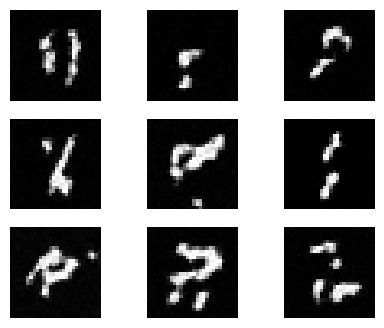

 10%|█         | 5/50 [01:00<08:52, 11.83s/it]


Epoch 6 | Loss = 20.012062773108482 | Grad Norm: 0.6097 | Noise Corr: 0.9790


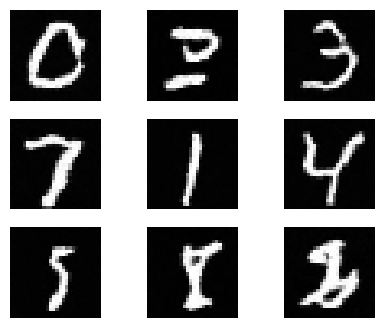

 20%|██        | 10/50 [02:01<07:52, 11.82s/it]


Epoch 11 | Loss = 18.17309113033116 | Grad Norm: 0.3142 | Noise Corr: 0.9803


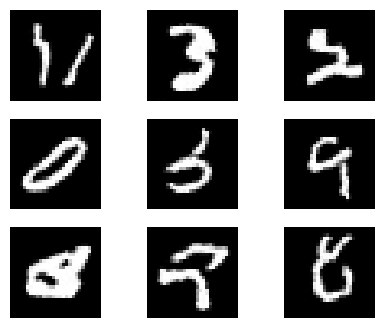

 30%|███       | 15/50 [03:02<06:53, 11.81s/it]


Epoch 16 | Loss = 17.582541538402438 | Grad Norm: 0.1784 | Noise Corr: 0.9833


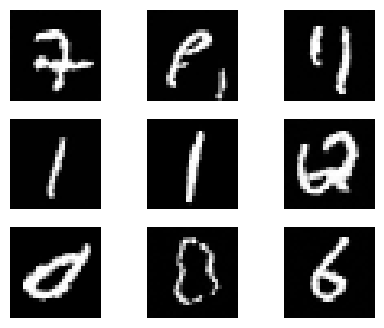

 40%|████      | 20/50 [04:03<05:54, 11.80s/it]


Epoch 21 | Loss = 17.13422111980617 | Grad Norm: 0.2557 | Noise Corr: 0.9790


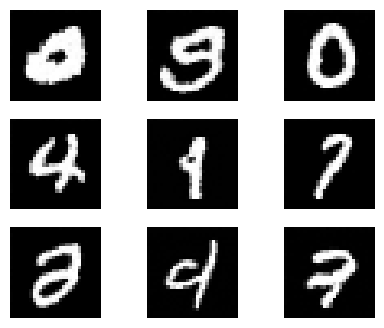

 50%|█████     | 25/50 [05:03<04:55, 11.81s/it]


Epoch 26 | Loss = 16.889570550993085 | Grad Norm: 0.3547 | Noise Corr: 0.9838


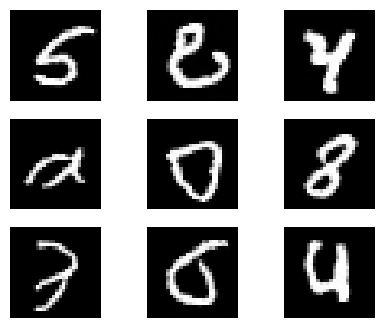

 60%|██████    | 30/50 [06:04<03:55, 11.79s/it]


Epoch 31 | Loss = 16.695358032360673 | Grad Norm: 0.1130 | Noise Corr: 0.9846


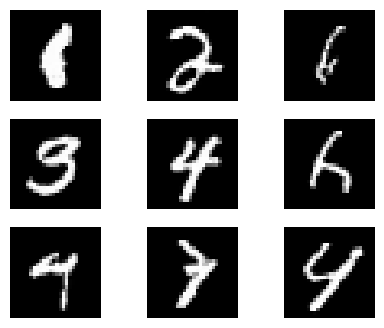

 70%|███████   | 35/50 [07:07<03:02, 12.15s/it]


Epoch 36 | Loss = 16.530545005574822 | Grad Norm: 0.1134 | Noise Corr: 0.9843


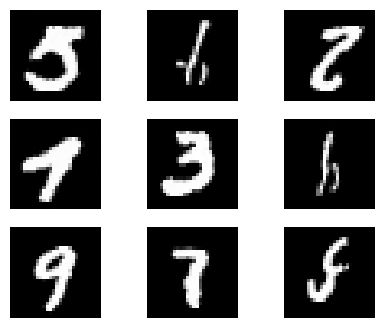

 80%|████████  | 40/50 [08:08<01:59, 11.92s/it]


Epoch 41 | Loss = 16.365096535533667 | Grad Norm: 0.1140 | Noise Corr: 0.9838


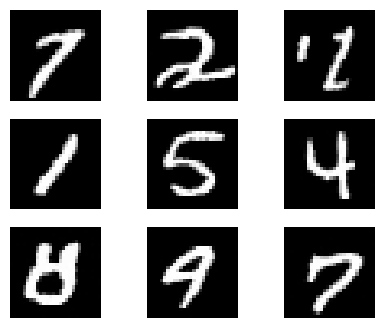

 90%|█████████ | 45/50 [09:09<00:59, 11.83s/it]


Epoch 46 | Loss = 16.361644430086017 | Grad Norm: 0.0991 | Noise Corr: 0.9827


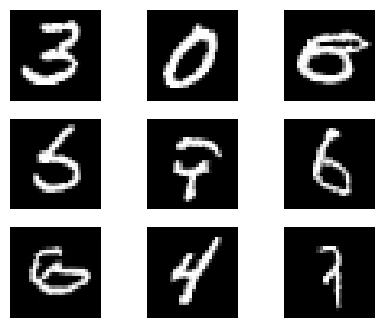

100%|██████████| 50/50 [10:09<00:00, 12.20s/it]


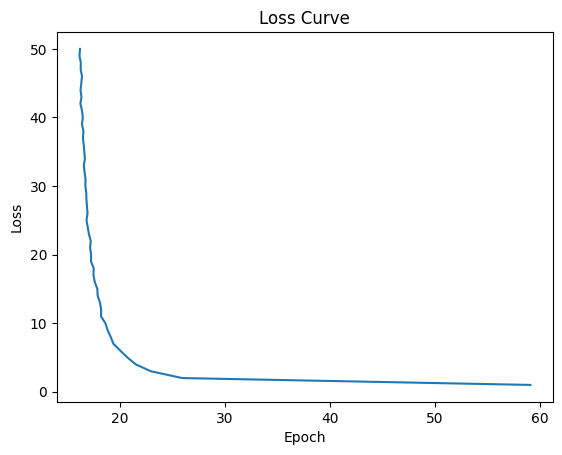

Model saved successfully!
Losses saved successfully!


In [34]:
losses = []
val_imgs, _ = next(iter(test_loader))
model.to(device)
for i in tqdm(range(EPOCHS)):
    acc_loss = 0
    for img, _ in train_loader:
        img = img.to(device)
        start = quad_diff.sample_timesteps(img.shape[0]).to(device)
        eps = torch.randn_like(img, device=device)
        xi = quad_diff.q_sample(img, start, eps)

        eps_hat = model(xi, start)

        loss = criterion(eps_hat, eps)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        acc_loss += loss.item()
    losses.append(acc_loss)

    if i % 5 == 0:
        total_norm = sum(p.grad.detach().data.norm(2).item() ** 2 for p in model.parameters() if p.grad is not None) ** 0.5
        corr = check_noise_correlation(model, quad_diff, val_imgs.to(device))
        print(f"\nEpoch {i+1} | Loss = {acc_loss} | Grad Norm: {total_norm:.4f} | Noise Corr: {corr:.4f}")
        periodic_sample_grids(model, quad_diff, 9, device)

plt.title("Loss Curve")
plt.plot(losses, np.arange(1,EPOCHS+1))
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

torch.save(model.state_dict(), "quad_model_weights.pth")
print("Model saved successfully!")
np.save("quad_losses.npy", np.array(losses))
print("Losses saved successfully!")

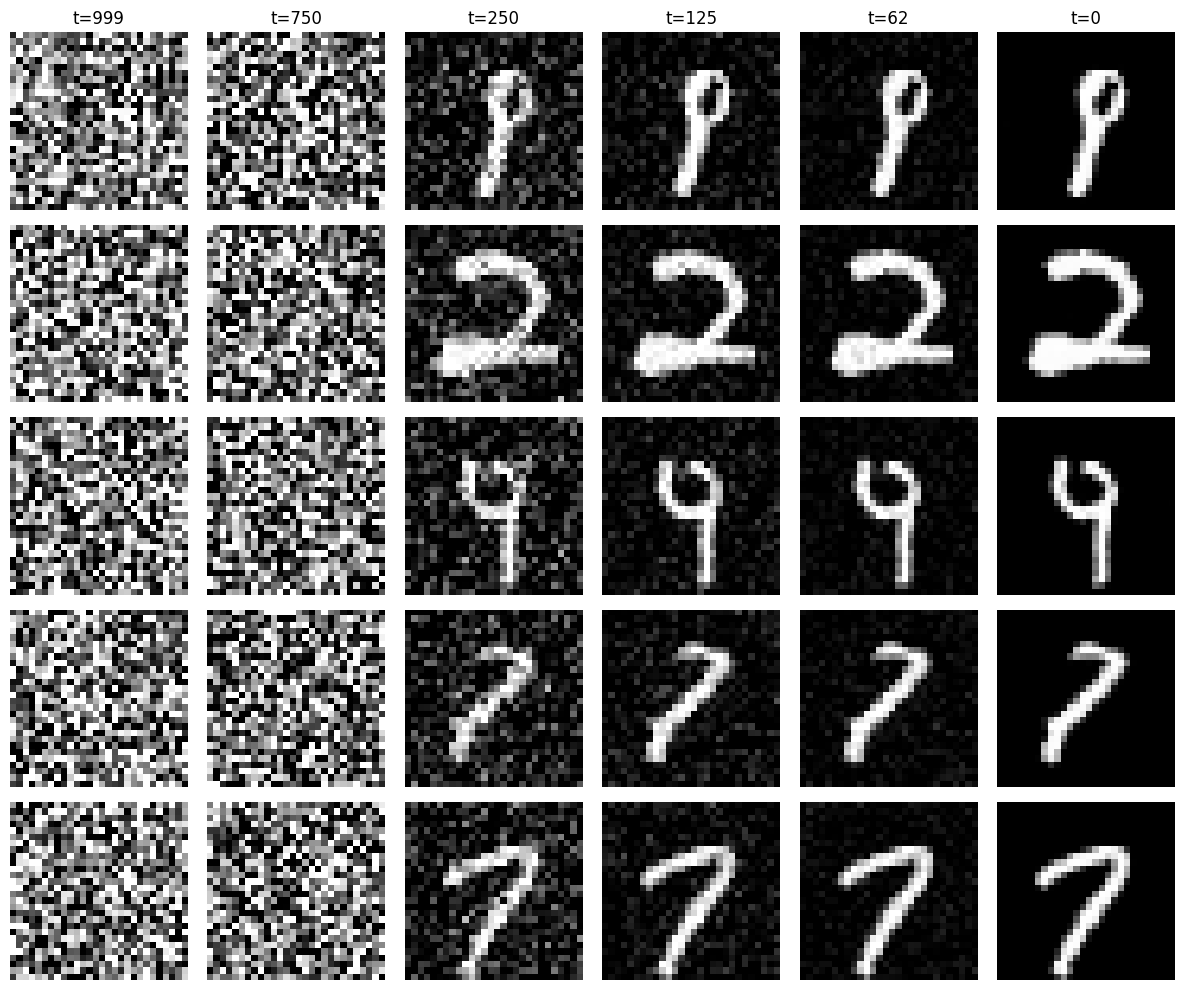

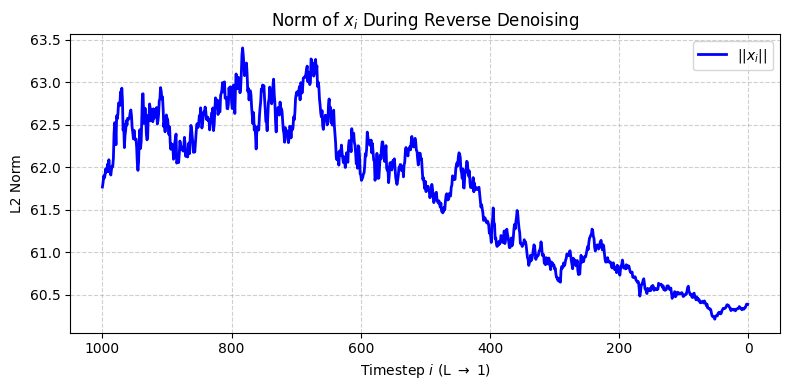

In [36]:
final_xi, intermediates, norms = ancestral_sample(model, quad_diff, count=5, device=device)
plot_ancestral_samples(intermediates, count=5)
plot_sampling_norms(norms, L=quad_diff.L)